In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import transforms
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import open_clip
from collections import OrderedDict
from tqdm.notebook import tqdm 

import os
import sys

sys.path.insert(0, os.path.abspath('../src'))  # make src/ importable

from models import (
    AdaGN, EncoderBlockAdaGN, DecoderBlock, ClipCondGeneratorAdaGN, GeneratorAdaGNAttention, ClipCondGeneratorFullyInjected, ClipProjCritic,
)

from cartoonset_inference_helpers import (plot_func, inference, analyze_noise_schedules, compare_train_test_reconstruction, run_dataset_average_distance_test, plot_comparative_clip_distributions_with_random, plot_latent_guidance_slerp, plot_text_interpolation)

/home/sikha/bse/NOT-GAN/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
device = "cpu"
IMG_SIZE = 64
train_size = 30_000
CHANNELS = 3
CLIP_DIM = 512
CH_CAP   = 512     # max channels in any conv layer
my_seed  = 42
rng = np.random.default_rng(my_seed)

df = pd.read_csv("../data/cartoon_with_embeddings.csv")

embeddings = np.load("../data/cartoon_clip_embeddings.npy")

final_model_path = "../models/CARTOONS/E21/fullinj_g5e-06_aoadam_s0.001_n80000_Gema_final.pth"

clip_model_path = "../models/CARTOONS/clip_cartoon_finetuned.pt"

D_path = "../models/CARTOONS/E21/fullinj_g5e-06_aoadam_s0.001_n80000_D_final.pth"

In [3]:
# Load the FINETUNED CLIP model and tokenizer
clip_model, _, _ = open_clip.create_model_and_transforms(
    model_name='ViT-B-32', 
    pretrained=None,  
    device=device
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

clip_state_dict = torch.load(clip_model_path, map_location=device)
clip_model.load_state_dict(clip_state_dict)

# ── FIX: Initialize D with the correct feature size  ──
G = ClipCondGeneratorFullyInjected(channels_img=3, features_g=64).to(device)

D = ClipProjCritic(channels_img=3, features_d=64).to(device) 

# 1. Load the raw state_dicts
state_dict = torch.load(final_model_path, map_location=device)
state_dict_D = torch.load(D_path, map_location=device)

from collections import OrderedDict

# Clean and load G
new_state_dict_G = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "") if k.startswith("module.") else k
    new_state_dict_G[name] = v
G.load_state_dict(new_state_dict_G)

# Clean and load D
new_state_dict_D = OrderedDict()
for k, v in state_dict_D.items():
    name = k.replace("module.", "") if k.startswith("module.") else k
    new_state_dict_D[name] = v
D.load_state_dict(new_state_dict_D)

<All keys matched successfully>

# Nice Part

### Here we just illustrated random samples generated from the model. All of them use the same seed for initial noise. The text descriptions are printed below 
(Null Token means the avergae vector from the train set, we don't provide any text prompt)

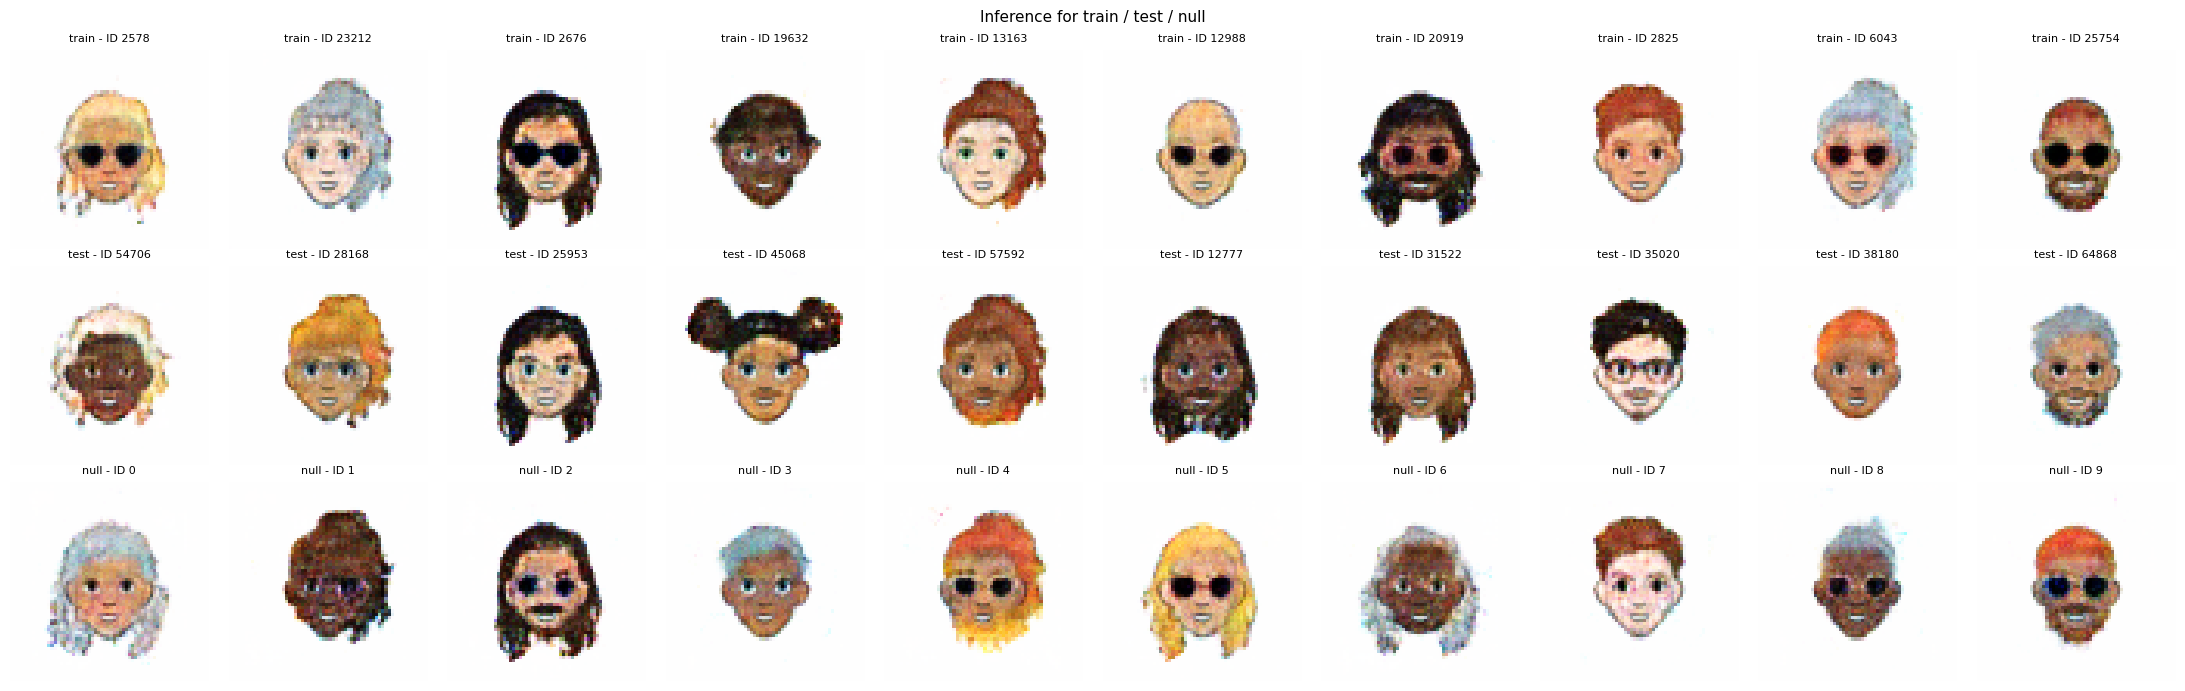


 TRAIN CLIP TEXT DESCRIPTIONS
ID  2578: A clean 2D graphic of a person featuring wearing a pair of blue heart-shaped glasses, medium straight honey blonde hair, a prominent brown skin tone, pale grey eyes, with no beard, a petite, short chin, medium-weight brow structures, and a long, rectangular face.
ID 23212: A cartoon profile depicting a person featuring with a completely bare jawline, with no eyewear present, bold eyebrows, a light peach complexion, a balanced, medium-sized chin, mid-length wavy completely white hair, pale grey eyes, and an oblong head shape with a flat chin.
ID  2676: A cartoon profile depicting a person featuring medium straight midnight black hair, a boxy, sharp face shape, wearing a pair of grey classic round-framed glasses, a subtle jaw edge, a smooth caramel complexion, delicately ultra-thin eyebrows, showing no facial hair, and bright blue eyes.
ID 19632: An artistic cartoon avatar of a person featuring a pear-shaped jaw, delicately ultra-thin eyebrows, de

In [4]:
plot_func(final_model_path, train_size, device, df, embeddings, my_seed, CHANNELS, IMG_SIZE)

### Here we test how the model performs on custom prompts that it has not seen

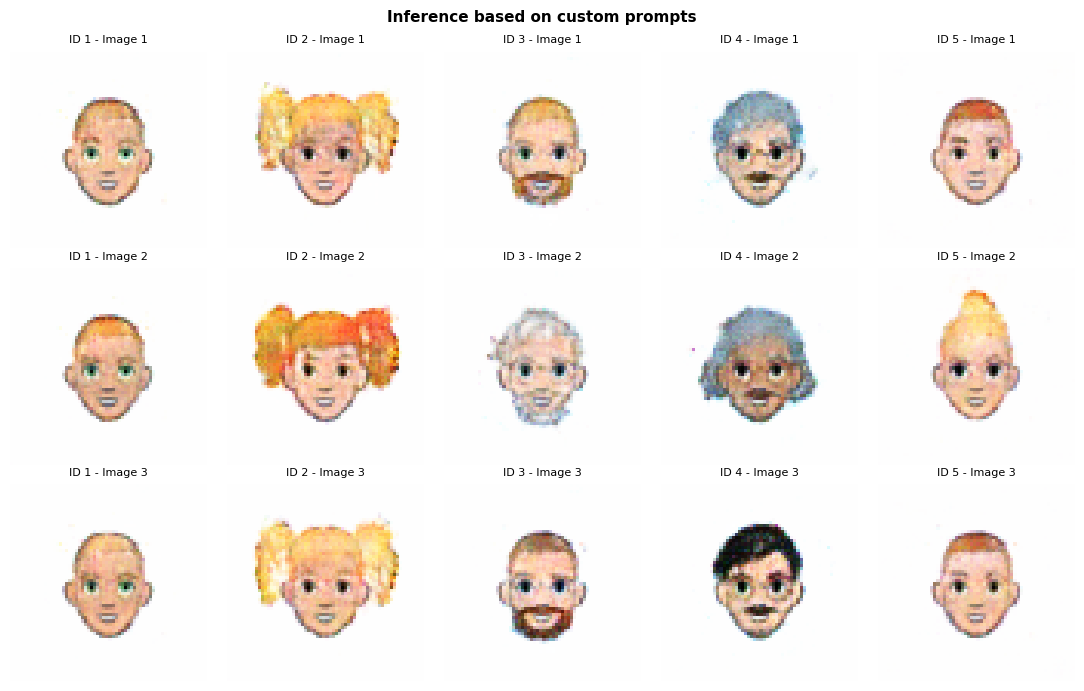


 GENERATED PROMPT DESCRIPTIONS
ID 1: A cartoon of a bald person with green eyes
ID 2: A 2D cartoon of a person with curly blonde pigtails and thick eyebrows
ID 3: An illustration of a person wearing blue glasses with mustache and short beard
ID 4: A person wih black hair and grey mustache
ID 5: no glasses


In [5]:
my_prompts = [
    "A cartoon of a bald person with green eyes",
    "A 2D cartoon of a person with curly blonde pigtails and thick eyebrows",
    "An illustration of a person wearing blue glasses with mustache and short beard",
    "A person wih black hair and grey mustache",
    "no glasses"
]

inference(
    text_prompts_list=my_prompts,
    model_path=final_model_path,
    device=device,
    clip_model=clip_model,
    tokenizer=tokenizer,
    CHANNELS=CHANNELS,
    IMG_SIZE=IMG_SIZE,
)

### Here we just test how the model responds to different initial noise schedules (I love the output of thw image 3 !)

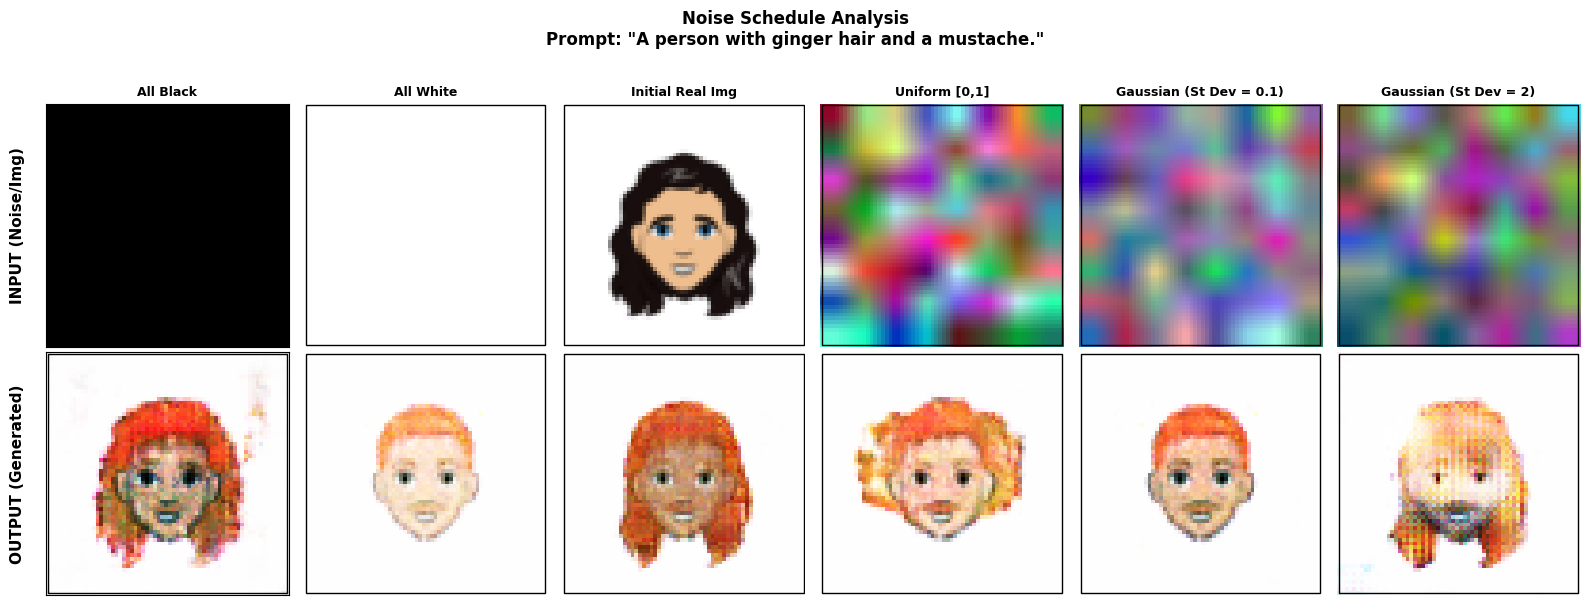

In [ ]:
analyze_noise_schedules(
    test_prompt="A person with ginger hair and a mustache.",
    model_path=final_model_path,
    device=device,
    clip_model=clip_model,
    tokenizer=tokenizer,
    CHANNELS=CHANNELS,
    IMG_SIZE=IMG_SIZE,
    image_path="../data/cs11467100668666121447.png"
)

### Here we just pass the train/test prompts to the model and compare it to the real image behind that prompt

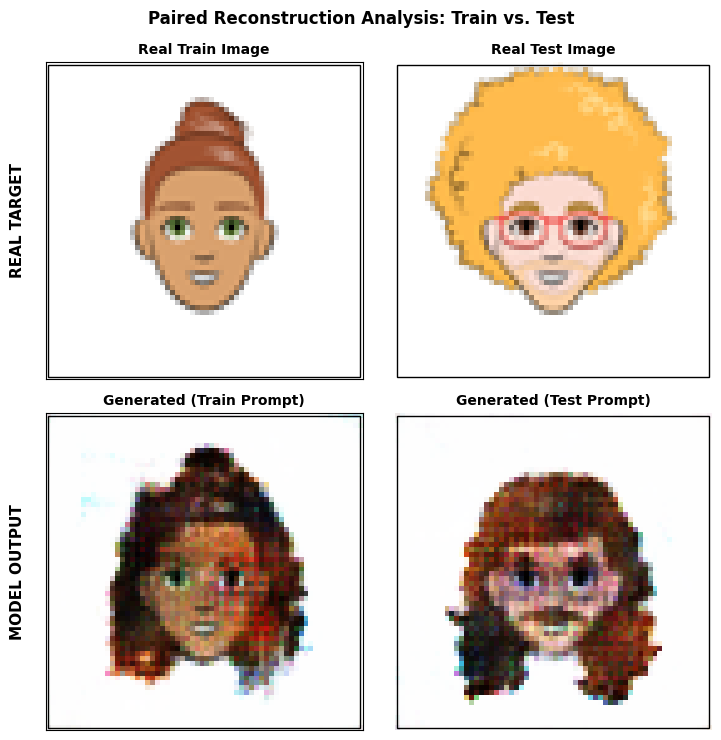

An artistic cartoon avatar of a person featuring showing no facial hair, with no glasses, light brown skin, medium brown hair gathered in a bun, dark green eyes, a highly prominent jaw extension, slender, thin eyebrows, and a perfectly round face.
A clean 2D graphic of a person featuring brown eyes, wearing a pair of red oversized circular wire spectacles, extremely pale, alabaster skin, a long, rectangular face, complemented by a subtle mustache and thin beard combo, long voluminous blonde curls, an elongated, long chin, and bold eyebrows.


In [18]:
train_image_path="../data/cs12803207845530317290.png"
test_image_path ="../data/cs939980702597145485.png"

train_desc="An artistic cartoon avatar of a person featuring showing no facial hair, with no glasses, light brown skin, medium brown hair gathered in a bun, dark green eyes, a highly prominent jaw extension, slender, thin eyebrows, and a perfectly round face."
test_desc="A clean 2D graphic of a person featuring brown eyes, wearing a pair of red oversized circular wire spectacles, extremely pale, alabaster skin, a long, rectangular face, complemented by a subtle mustache and thin beard combo, long voluminous blonde curls, an elongated, long chin, and bold eyebrows."


compare_train_test_reconstruction(
    model_path=final_model_path,
    device=device,
    clip_model=clip_model,
    tokenizer=tokenizer,
    CHANNELS=CHANNELS,
    IMG_SIZE=IMG_SIZE,
    train_path=train_image_path,
    test_path = test_image_path,
    train_desc = train_desc,
    test_desc = test_desc
)

### 3 Samples Test

In [8]:
run_dataset_average_distance_test(df, embeddings, final_model_path, device)

      DATASET-WIDE AVERAGED DISTANCE ANALYSIS
1. [TEST SET] (CLOSEST MATCH IN TRAIN SET) (Average out of 1,000 samples)
   - Mean Best Cosine Similarity:  0.7834
   - Mean Nearest Neighbor L2 Dist: 0.6550
----------------------------------------------------------------------
2. [TEST SET] (NULL TOKEN BASELINE) (Average out of 1,000 samples)
   - Mean Cosine Similarity:       0.0141
   - Mean L2 Distance:             1.3978
----------------------------------------------------------------------
3. [TRAIN SET] (NULL TOKEN GLOBAL BASELINE) (Average out of 80,000 samples)
   - Mean Cosine Similarity:       0.0162
   - Mean L2 Distance:             1.3963


### Checking cos similarity between prompts and images (grey is baseline which means that we randomly permuted embeddings of prompts and images and computed avg cos similarity)

Processing TRAINING partition...


100%|██████████| 20/20 [00:55<00:00,  2.78s/it]


Processing TESTING partition...


100%|██████████| 20/20 [01:02<00:00,  3.13s/it]


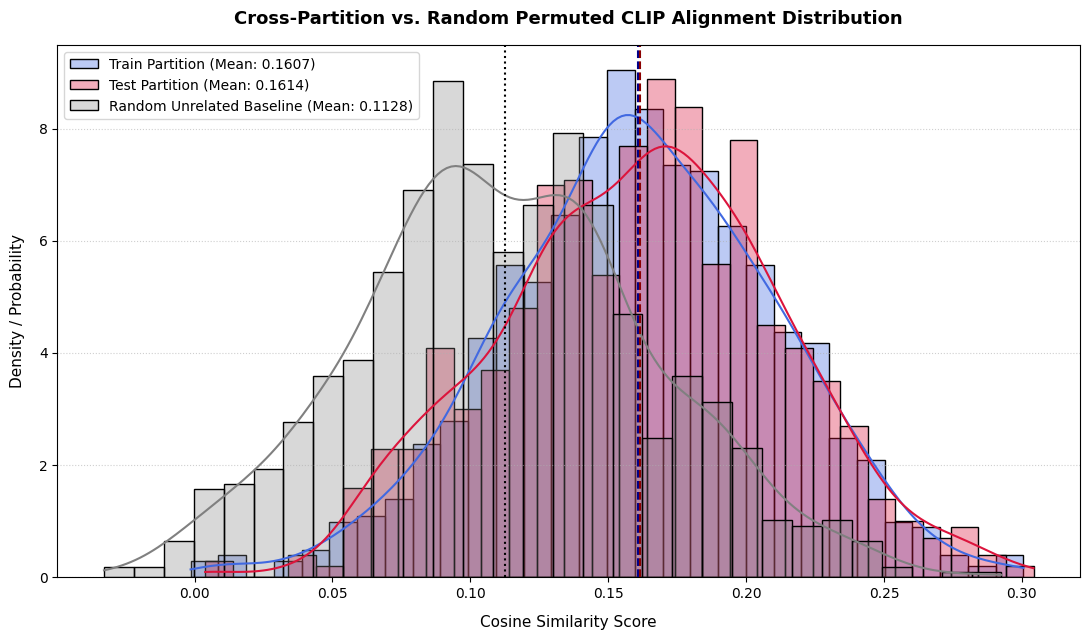

In [9]:
plot_comparative_clip_distributions_with_random(df, embeddings, final_model_path, device, clip_model, CHANNELS, IMG_SIZE)

### SLERP

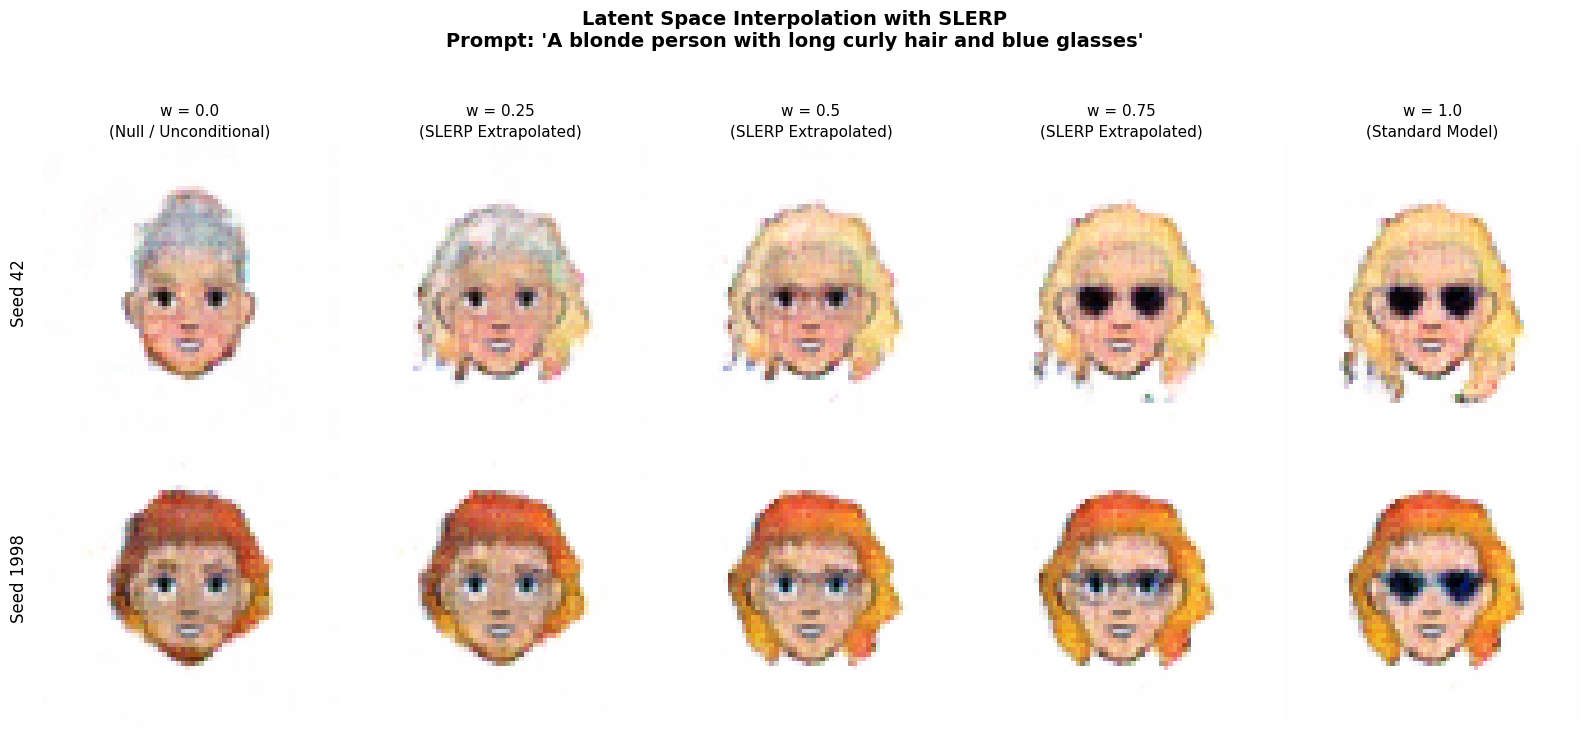

In [14]:
# To run it:
plot_latent_guidance_slerp("A blonde person with long curly hair and blue glasses", [0.00, 0.25, 0.50, 0.75, 1.00], G, clip_model, tokenizer, device)

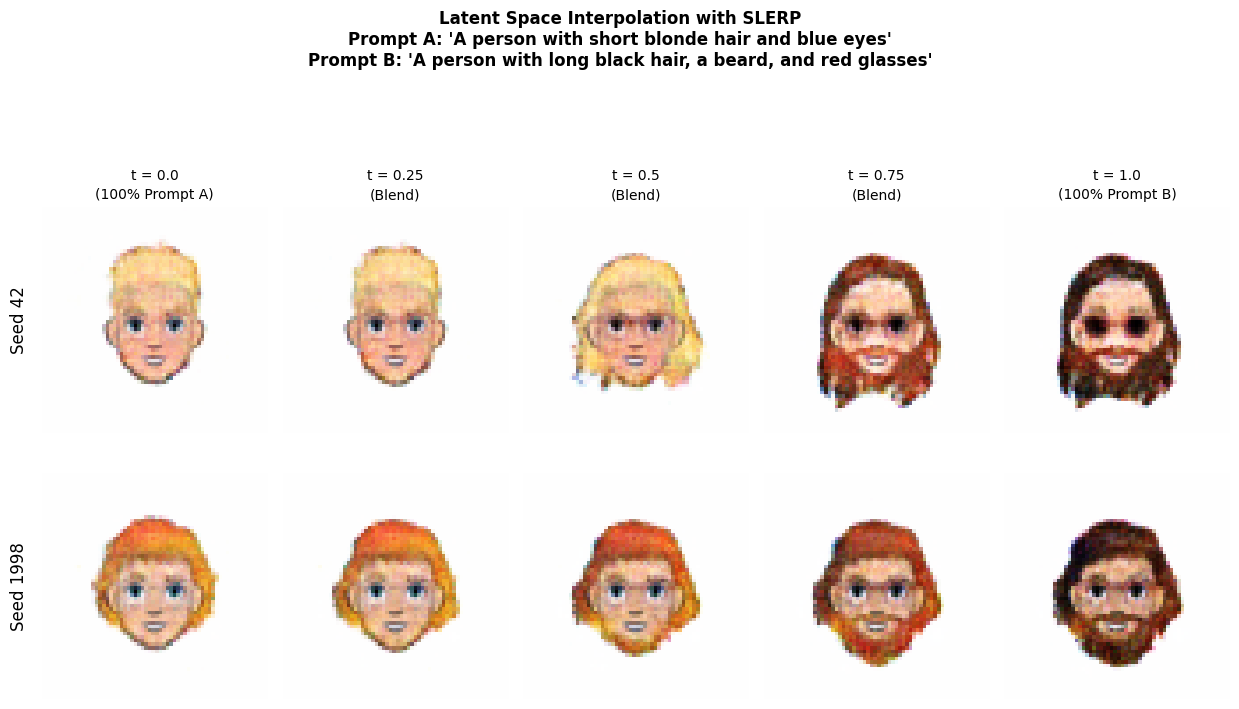

In [17]:
prompt_1 = "A person with short blonde hair and blue eyes"
prompt_2 = "A person with long black hair, a beard, and red glasses"

# Using 5 evenly spaced steps from 0.0 to 1.0
t_steps = [0.0, 0.25, 0.5, 0.75, 1.0]

plot_text_interpolation(prompt_1, prompt_2, t_steps, G, clip_model, tokenizer, device)